# 03. Probability, Randomness, and Expectation

Probability is often introduced with dice, cards, and coins. Those examples are useful, but in decision science they are only warm-up exercises. The real reason probability matters is that operational systems are uncertain even when they are structured. The next seller-support ticket may be urgent or routine. The next queue may be light or congested. The next response may meet the service target or miss it. None of this is pure chaos, but none of it is fully predictable either.

We develop the probability language needed to reason about that uncertainty. We will work in the same synthetic marketplace support setting as the first two lectures, but now the focus shifts from defining data objects to quantifying uncertain events, random variables, expected outcomes, and the long-run quantities that matter for planning.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain probability as a language for uncertain operational events in applied decision settings.
2. Define events and compute marginal, joint, and union probabilities from a realistic data-generating process.
3. Distinguish random variables from events and interpret indicators as probability-carrying variables.
4. Explain expectation as a long-run average and as a planning quantity.
5. Use the law of total expectation to decompose an overall mean into contributions from operating regimes.
6. Interpret variance and covariance as measures of instability and co-movement, while keeping causal claims separate.
7. Turn expected-value calculations into a professional operational recommendation with explicit uncertainty.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 24)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Randomness in Operations Is Structured, Not Magical

A common beginner intuition is that randomness means disorder. In applied statistics, that is usually too crude. Operational randomness often arises because many drivers act at once: customer urgency, queue congestion, region, channel, staffing, and ordinary idiosyncratic noise. The exact next outcome is uncertain, but the distribution of outcomes still has structure.

That distinction matters. If a process were truly patternless, probability would be nearly useless beyond bookkeeping. But most business systems are neither deterministic nor patternless. They are partially regular, partially noisy, and therefore probabilistic.


| Probability Object | Interpretation Here |
|---|---|
| Experiment | Observe the next support ticket or the next operational day |
| Event | A condition such as `urgent`, `phone`, or `response breach` occurs |
| Random variable | A numerical quantity such as response time or service-credit cost |
| Probability | Long-run relative frequency or model-based degree of uncertainty |
| Expectation | Long-run average value of a random variable |
| Variance | Typical squared deviation from the expected value |
| Covariance | How two random variables move together |


This table is small, but it organizes the rest of the lecture. Events are yes-or-no propositions. Random variables assign numbers to uncertain outcomes. Probability summarizes how often events occur. Expectation summarizes what a random variable averages to in the long run.

These are not isolated definitions. They are the minimum language required to translate uncertainty into planning. If leadership wants to know the expected daily cost of a premium service promise, that is an expectation question. If they want to know how often a bad operational day will happen, that is a probability question. If they want to know whether queue pressure and response times move together, that is a covariance question.

## 2. Simulating an Operational Probability Space

We simulate a large ticket population so that probabilities can be estimated empirically from a realistic support workflow. This population is not meant to be a perfect business twin. It is a controlled teaching environment where the next ticket is genuinely uncertain but the underlying process still has interpretable structure.

### Dataset and Experiment Design

Each row represents one possible support ticket that could arrive under the operating conditions of the service system. The row includes seller tier, priority status, ticket severity, intake channel, arrival timing, queue congestion, analyst experience, first-response time, breach status, and the service credit owed when the premium promise is missed.

The experiment treats this large simulated population as an empirical probability space. We repeatedly ask what happens if the next ticket is drawn from this process, then calculate event probabilities, conditional probabilities, expectations, variances, covariances, and planning quantities from the rows. We connect probability language to support operations instead of relying on abstract coin-flip examples.

In [2]:
# Define helper functions and reusable utilities for this section.
rng = np.random.default_rng(2033)

def sigmoid(x):
    """
    Transform a linear score into a probability with the logistic function.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
    
    Returns:
        A scalar or NumPy array containing the logistic transform of `x`, useful for converting linear scores into probabilities.
    
    Idea:
        Convert additive risk drivers into bounded probabilities, allowing synthetic event rates to respond smoothly to covariates.
    """
    return 1.0 / (1.0 + np.exp(-x))


n_tickets = 90_000
seller_tier_levels = np.array(["standard", "growth", "enterprise"])
region_levels = np.array(["North", "South", "West", "Central"])
severity_levels = ["low", "medium", "high", "urgent"]
channel_levels = np.array(["chat", "email", "phone"])
day_levels = np.array(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

seller_tier = rng.choice(seller_tier_levels, size=n_tickets, p=[0.60, 0.26, 0.14])
region = rng.choice(region_levels, size=n_tickets, p=[0.26, 0.23, 0.30, 0.21])
day_of_week = rng.choice(day_levels, size=n_tickets, p=[0.16, 0.16, 0.16, 0.16, 0.16, 0.10, 0.10])

priority_contract = (
    (seller_tier == "enterprise")
    | ((seller_tier == "growth") & (rng.random(n_tickets) < 0.38))
).astype(int)

tier_complexity_shift = {"standard": -0.16, "growth": 0.06, "enterprise": 0.28}
region_complexity_shift = {"North": -0.08, "South": 0.02, "West": 0.15, "Central": 0.00}

latent_complexity = rng.normal(
    loc=np.vectorize(tier_complexity_shift.get)(seller_tier)
    + np.vectorize(region_complexity_shift.get)(region)
    + 0.08 * (day_of_week == "Mon")
    + 0.05 * (day_of_week == "Fri"),
    scale=0.78,
    size=n_tickets,
)

severity_score = latent_complexity + 0.20 * priority_contract + rng.normal(0, 0.88, size=n_tickets)
severity = pd.cut(
    severity_score,
    bins=[-np.inf, -0.55, 0.35, 1.10, np.inf],
    labels=severity_levels,
)
severity = pd.Categorical(severity, categories=severity_levels, ordered=True)

channel_probability_map = {
    "low": [0.62, 0.28, 0.10],
    "medium": [0.44, 0.36, 0.20],
    "high": [0.24, 0.39, 0.37],
    "urgent": [0.08, 0.31, 0.61],
}

channel = np.empty(n_tickets, dtype=object)
for sev, probs in channel_probability_map.items():
    mask = severity == sev
    channel[mask] = rng.choice(channel_levels, size=mask.sum(), p=probs)

overnight_prob = sigmoid(
    -2.05
    + 0.60 * (severity == "urgent").astype(float)
    + 0.26 * (channel == "phone").astype(float)
    + 0.22 * (day_of_week == "Sat").astype(float)
    + 0.22 * (day_of_week == "Sun").astype(float)
)
overnight = rng.binomial(1, overnight_prob)

region_load_shift = {"North": -0.10, "South": 0.04, "West": 0.20, "Central": 0.00}
severity_load_shift = {"low": -0.20, "medium": 0.04, "high": 0.34, "urgent": 0.76}

queue_load = rng.normal(
    loc=np.vectorize(region_load_shift.get)(region)
    + np.vectorize(severity_load_shift.get)(severity.astype(str))
    + 0.62 * overnight
    + 0.16 * (day_of_week == "Mon").astype(float),
    scale=0.72,
    size=n_tickets,
)
queue_load = np.clip(queue_load, -2.2, 3.6)

region_experience_shift = {"North": 0.10, "South": 0.03, "West": -0.08, "Central": 0.05}
analyst_experience = rng.normal(
    loc=0.28
    + np.vectorize(region_experience_shift.get)(region)
    - 0.20 * queue_load
    - 0.10 * (severity == "urgent").astype(float),
    scale=0.82,
    size=n_tickets,
)
analyst_experience = np.clip(analyst_experience, -2.5, 2.5)

first_response_log = (
    1.98
    + np.select(
        [severity == "low", severity == "medium", severity == "high", severity == "urgent"],
        [-0.28, 0.00, 0.42, 0.82],
    )
    + 0.30 * queue_load
    + 0.22 * overnight
    + 0.12 * (channel == "phone").astype(float)
    - 0.13 * analyst_experience
    + rng.normal(0, 0.34, size=n_tickets)
)
first_response_minutes = np.exp(first_response_log)
response_breach = (first_response_minutes > 15).astype(int)

service_credit = np.where(
    (priority_contract == 1) & (response_breach == 1),
    90.0,
    np.where(response_breach == 1, 20.0, 0.0),
)

tickets = pd.DataFrame(
    {
        "seller_tier": seller_tier,
        "region": region,
        "day_of_week": day_of_week,
        "priority_contract": priority_contract,
        "severity": severity,
        "channel": channel,
        "overnight": overnight,
        "queue_load": queue_load,
        "analyst_experience": analyst_experience,
        "first_response_minutes": first_response_minutes,
        "response_breach": response_breach,
        "service_credit": service_credit,
    }
)

operational_overview = pd.DataFrame(
    [
        {"quantity": "Tickets in probability space", "value": len(tickets)},
        {"quantity": "Share of priority-contract tickets", "value": tickets["priority_contract"].mean()},
        {"quantity": "Share of urgent tickets", "value": (tickets["severity"] == "urgent").mean()},
        {"quantity": "Share of phone tickets", "value": (tickets["channel"] == "phone").mean()},
        {"quantity": "Response breach rate", "value": tickets["response_breach"].mean()},
        {"quantity": "Mean first-response minutes", "value": tickets["first_response_minutes"].mean()},
        {"quantity": "Mean service credit per ticket", "value": tickets["service_credit"].mean()},
    ]
)

smart_display(operational_overview)

,quantity,value
0,Tickets in probability space,90000.000
1,Share of priority-contract tickets,0.240
2,Share of urgent tickets,0.193
3,Share of phone tickets,0.284
4,Response breach rate,0.275
5,Mean first-response minutes,12.802
6,Mean service credit per ticket,11.553


This simulated ticket population is our empirical probability space. Every row corresponds to one possible ticket realization from the underlying service process. Because the population is large, relative frequencies in the data provide a clean approximation to probabilities under the assumed workflow.

The key pedagogical point is that probabilities are attached to a process. They are not detached facts. Change the routing rules, the staffing system, or the case mix, and the probabilities change as well.

## 3. Events, Joint Events, and Union Probabilities

An event is a set of possible outcomes. We will use the following notation:

- $A$: the next ticket is urgent;
- $B$: the next ticket arrives through the phone channel;
- $C$: the next ticket misses the 15-minute response target;
- $D$: the next ticket belongs to a priority-contract seller.

From these events we can define intersections and unions. For example, $A \cap B$ is the event that the next ticket is both urgent and phone-based. The union $A \cup B$ is the event that at least one of those two conditions holds.

A central identity is the inclusion-exclusion rule:

$$
P(A \cup B) = P(A) + P(B) - P(A \cap B)
$$

The subtraction is necessary because the overlap gets counted twice if we simply add the marginal probabilities.


In [3]:
# Build a summary table that supports the interpretation in the surrounding notes.
A = tickets["severity"] == "urgent"
B = tickets["channel"] == "phone"
C = tickets["response_breach"] == 1
D = tickets["priority_contract"] == 1

event_table = pd.DataFrame(
    [
        {"quantity": "P(A): urgent ticket", "value": A.mean()},
        {"quantity": "P(B): phone ticket", "value": B.mean()},
        {"quantity": "P(C): response breach", "value": C.mean()},
        {"quantity": "P(D): priority-contract ticket", "value": D.mean()},
        {"quantity": "P(A and B): urgent and phone", "value": (A & B).mean()},
        {"quantity": "P(A and C): urgent and breach", "value": (A & C).mean()},
        {"quantity": "P(B and C): phone and breach", "value": (B & C).mean()},
        {"quantity": "P(A or B)", "value": (A | B).mean()},
        {"quantity": "P(A) + P(B) - P(A and B)", "value": A.mean() + B.mean() - (A & B).mean()},
    ]
)

smart_display(event_table)


,quantity,value
0,P(A): urgent ticket,0.193
1,P(B): phone ticket,0.284
2,P(C): response breach,0.275
3,P(D): priority-contract ticket,0.240
4,P(A and B): urgent and phone,0.119
5,P(A and C): urgent and breach,0.166
6,P(B and C): phone and breach,0.149
7,P(A or B),0.358
8,P(A) + P(B) - P(A and B),0.358


The event table makes probability bookkeeping explicit. Urgent tickets and phone tickets overlap, so adding their marginal probabilities would overstate the chance that a ticket is urgent or phone-based. The inclusion-exclusion row matches the directly computed union, which is the basic check that the event definitions are being used correctly.

This matters in operational planning because risk categories rarely partition cleanly. A ticket can be urgent, arrive by phone, and breach the response target. Good probability work prevents the same risk from being counted twice or treated as if it belonged to only one bucket.


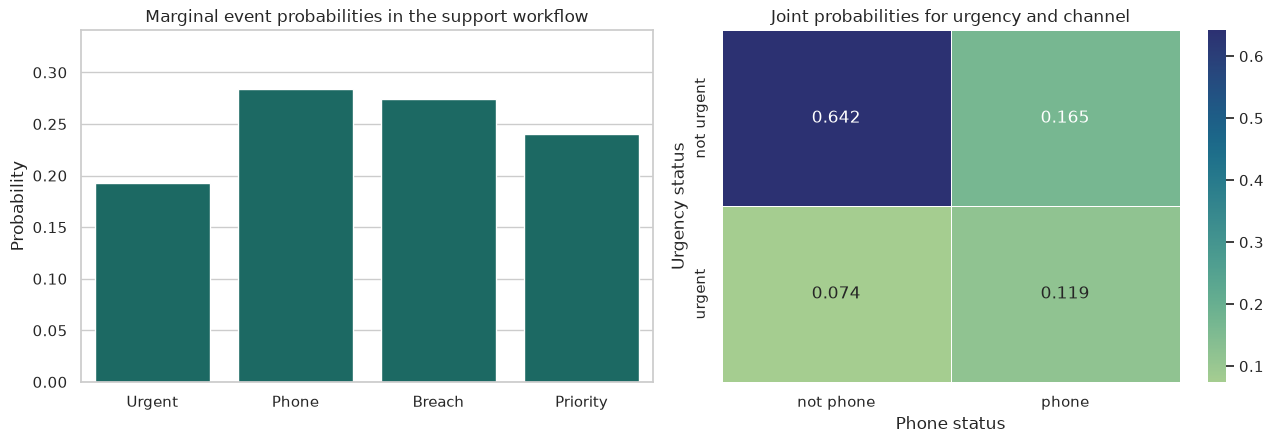

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
event_plot = pd.DataFrame(
    {
        "event": ["Urgent", "Phone", "Breach", "Priority"],
        "probability": [A.mean(), B.mean(), C.mean(), D.mean()],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))

sns.barplot(data=event_plot, x="event", y="probability", color="#0f766e", ax=axes[0])
axes[0].set_title("Marginal event probabilities in the support workflow")
axes[0].set_xlabel("")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, event_plot["probability"].max() * 1.2)

joint_matrix = pd.DataFrame(
    {
        "not phone": [((~A) & (~B)).mean(), (A & (~B)).mean()],
        "phone": [((~A) & B).mean(), (A & B).mean()],
    },
    index=["not urgent", "urgent"],
)
sns.heatmap(joint_matrix, annot=True, fmt=".3f", cmap="crest", linewidths=0.5, ax=axes[1])
axes[1].set_title("Joint probabilities for urgency and channel")
axes[1].set_xlabel("Phone status")
axes[1].set_ylabel("Urgency status")

plt.tight_layout()
plt.show()


The calculation verifies the inclusion-exclusion rule numerically. The computed value of $P(A \cup B)$ matches the decomposition using marginal and joint probabilities, which is exactly what probability theory says should happen.

More importantly, the event probabilities already have operational meaning. If the breach probability is substantial, then a service promise is risky. If urgent tickets and phone tickets overlap often, then staffing for high-intensity communication channels matters disproportionately. Probability is doing business translation here, with arithmetic serving the decision question.

## 4. Random Variables and the Meaning of Expectation

An event answers a yes-or-no question. A random variable maps uncertain outcomes to numbers.

Three useful random variables in this setting are:

- $X$: first-response minutes for the next ticket;
- $B$: an indicator that equals 1 if the next ticket breaches the response target and 0 otherwise;
- $L$: service-credit dollars owed on the next ticket.

The expectation of a random variable is its long-run average. In discrete form,

$$
E[X] = \sum_x x\,P(X=x)
$$

and for an indicator variable,

$$
E[B] = P(B=1)
$$

That last identity is especially important. Binary indicators let us translate probability questions into expected-value language and back again.


In [5]:
# Build a summary table that supports the interpretation in the surrounding notes.
expectation_table = pd.DataFrame(
    [
        {
            "random_variable": "X = first-response minutes",
            "interpretation": "Long-run average response time",
            "expectation": tickets["first_response_minutes"].mean(),
            "variance": tickets["first_response_minutes"].var(),
        },
        {
            "random_variable": "B = response breach indicator",
            "interpretation": "Long-run breach probability",
            "expectation": tickets["response_breach"].mean(),
            "variance": tickets["response_breach"].var(),
        },
        {
            "random_variable": "L = service credit on next ticket",
            "interpretation": "Expected credit cost per ticket",
            "expectation": tickets["service_credit"].mean(),
            "variance": tickets["service_credit"].var(),
        },
    ]
)

smart_display(expectation_table)


,random_variable,interpretation,expectation,variance
0,X = first-response minutes,Long-run average response time,12.802,122.325
1,B = response breach indicator,Long-run breach probability,0.275,0.199
2,L = service credit on next ticket,Expected credit cost per ticket,11.553,643.245


The expectation table illustrates three different but connected readings of the same concept.

For $X$, expectation is a long-run average measured in minutes. For $B$, expectation is simply a probability because indicators average to the frequency of ones. For $L$, expectation becomes a budget quantity: the average service-credit cost attached to one ticket.

This is why expected values are central in data science for decisions. They convert uncertain processes into planning numbers, even when any single realization can be far from the average.

## 5. The Law of Total Expectation

Overall expectations are often weighted mixtures of regime-specific expectations. If severity changes response behavior, then the overall expected response time can be decomposed across severity levels:

$$
E[X] = \sum_s E[X \mid S=s] P(S=s)
$$

This is one of the most useful identities in applied statistics. It reminds us that an overall mean is not a mysterious monolith. It is a weighted average of conditional means.


In [6]:
# Build a summary table that supports the interpretation in the surrounding notes.
severity_expectation = (
    tickets.groupby("severity", observed=True)
    .agg(
        probability=("first_response_minutes", lambda x: len(x) / len(tickets)),
        conditional_mean_response=("first_response_minutes", "mean"),
        conditional_mean_credit=("service_credit", "mean"),
    )
    .reindex(severity_levels)
)

severity_expectation["response_contribution"] = (
    severity_expectation["probability"] * severity_expectation["conditional_mean_response"]
)
severity_expectation["credit_contribution"] = (
    severity_expectation["probability"] * severity_expectation["conditional_mean_credit"]
)

severity_expectation.loc["total"] = {
    "probability": severity_expectation["probability"].sum(),
    "conditional_mean_response": np.nan,
    "conditional_mean_credit": np.nan,
    "response_contribution": severity_expectation["response_contribution"].sum(),
    "credit_contribution": severity_expectation["credit_contribution"].sum(),
}

smart_display(severity_expectation)


,probability,conditional_mean_response,conditional_mean_credit,response_contribution,credit_contribution
severity,,,,,
low,0.308,5.947,0.420,1.833,0.129
medium,0.292,8.606,2.633,2.510,0.768
high,0.207,14.849,15.362,3.076,3.183
urgent,0.193,27.895,38.733,5.382,7.473
total,1.000,NaN,NaN,12.802,11.553


The expectation calculation turns uncertainty into a planning quantity. It does not promise that any single period will equal the average; it gives a baseline for repeated decisions.


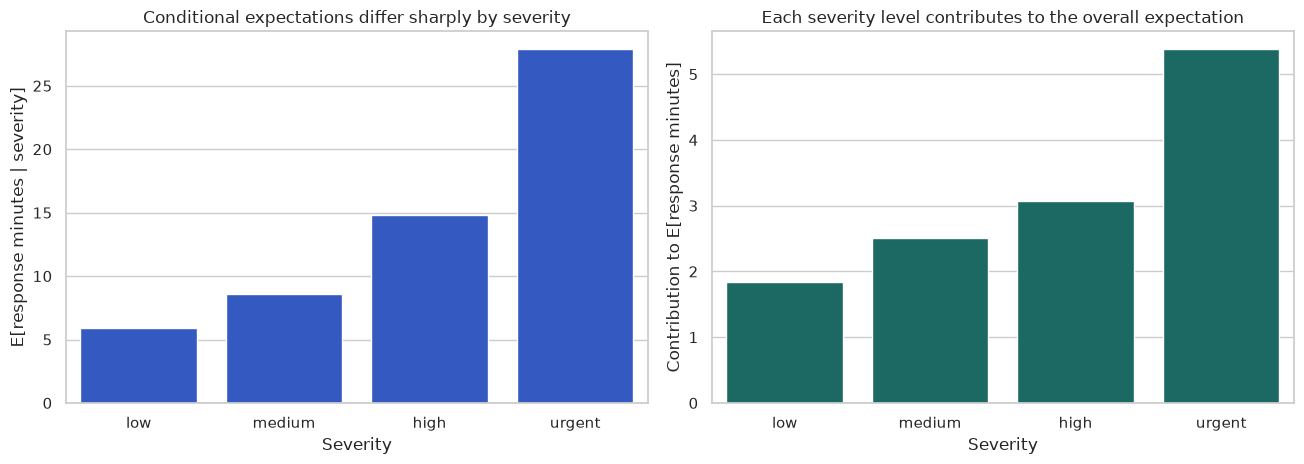

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

severity_plot = severity_expectation.drop(index="total")

sns.barplot(
    data=severity_plot.reset_index(),
    x="severity",
    y="conditional_mean_response",
    color="#1d4ed8",
    ax=axes[0],
)
axes[0].set_title("Conditional expectations differ sharply by severity")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("E[response minutes | severity]")

sns.barplot(
    data=severity_plot.reset_index(),
    x="severity",
    y="response_contribution",
    color="#0f766e",
    ax=axes[1],
)
axes[1].set_title("Each severity level contributes to the overall expectation")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Contribution to E[response minutes]")

plt.tight_layout()
plt.show()


The left panel shows that severity-specific expected response times differ substantially. The right panel then adds the missing piece: each severity group contributes to the overall expectation in proportion to both its size and its conditional mean.

This is a core decision-science habit. When an overall mean changes, we should ask whether the change came from within-group behavior, from case-mix proportions, or from both. The law of total expectation gives that question a clean mathematical form.

## 6. Expectation as a Long-Run Average

Expectation is often misunderstood as a promise about a single realization. That is not what it means. The expected service credit per ticket does not say what the next ticket will cost. It says what the average cost will settle toward over many similar tickets.

We can see this directly by simulating many operational days from the same ticket distribution.


In [8]:
# Build a summary table that supports the interpretation in the surrounding notes.
priority_tickets = tickets.loc[tickets["priority_contract"] == 1].copy().reset_index(drop=True)
n_days = 1000
tickets_per_day = 260

daily_rows = []
for day_id in range(n_days):
    day_sample = priority_tickets.sample(n=tickets_per_day, replace=True, random_state=5000 + day_id)
    daily_rows.append(
        {
            "day_id": day_id + 1,
            "mean_response_minutes": day_sample["first_response_minutes"].mean(),
            "breach_rate": day_sample["response_breach"].mean(),
            "total_service_credit": day_sample["service_credit"].sum(),
            "credit_per_ticket": day_sample["service_credit"].mean(),
        }
    )

daily_metrics = pd.DataFrame(daily_rows)
daily_metrics["running_average_credit"] = daily_metrics["credit_per_ticket"].expanding().mean()
expected_credit_per_ticket = priority_tickets["service_credit"].mean()

daily_metrics.head()


,day_id,mean_response_minutes,breach_rate,total_service_credit,credit_per_ticket,running_average_credit
0,1,16.447,0.377,8820.000,33.923,33.923
1,2,16.342,0.373,8730.000,33.577,33.750
2,3,15.067,0.335,7830.000,30.115,32.538
3,4,16.032,0.385,9000.000,34.615,33.058
4,5,15.093,0.362,8460.000,32.538,32.954


The expectation calculation turns uncertainty into a planning quantity. It does not promise that any single period will equal the average; it gives a baseline for repeated decisions.


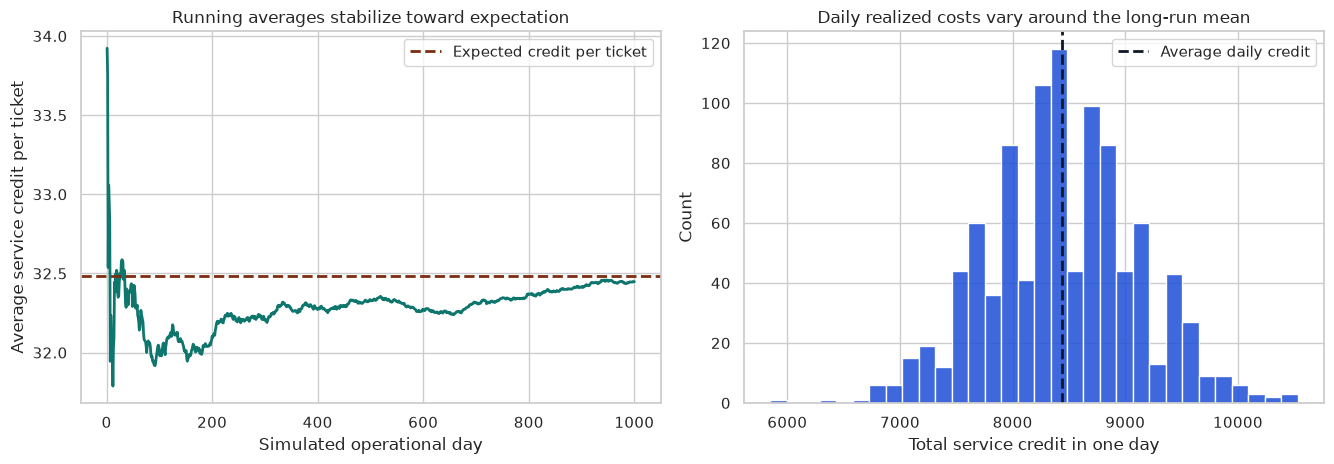

In [9]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

axes[0].plot(daily_metrics["day_id"], daily_metrics["running_average_credit"], color="#0f766e", linewidth=2)
axes[0].axhline(expected_credit_per_ticket, color="#7c2d12", linestyle="--", linewidth=2, label="Expected credit per ticket")
axes[0].set_title("Running averages stabilize toward expectation")
axes[0].set_xlabel("Simulated operational day")
axes[0].set_ylabel("Average service credit per ticket")
axes[0].legend()

sns.histplot(daily_metrics["total_service_credit"], bins=32, color="#1d4ed8", alpha=0.85, ax=axes[1])
axes[1].axvline(daily_metrics["total_service_credit"].mean(), color="#111827", linestyle="--", linewidth=2, label="Average daily credit")
axes[1].set_title("Daily realized costs vary around the long-run mean")
axes[1].set_xlabel("Total service credit in one day")
axes[1].legend()

plt.tight_layout()
plt.show()


The running-average plot shows the meaning of expectation more clearly than a formula alone can. Single days bounce around. Some days are cheap, others expensive. But the running average becomes progressively more stable and drifts toward the expected cost per ticket.

The histogram shows the companion idea: long-run averages can be stable while short-run realizations remain noisy. This is exactly why operational planning needs both expectation and variability. A budget based only on the mean can still be surprised by a bad week.

## 7. Variance and Covariance

Expectation alone is not enough. Two uncertain quantities can have the same expected value and very different instability. Variance formalizes that instability:

$$
\mathrm{Var}(X) = E[(X - E[X])^2]
$$

Covariance measures whether two random variables move together:

$$
\mathrm{Cov}(X, Y) = E[(X-E[X])(Y-E[Y])]
$$

Positive covariance means large values of one variable tend to appear with large values of the other. Negative covariance means they tend to move in opposite directions. Neither quantity is causal by itself.


In [10]:
# Build a summary table that supports the interpretation in the surrounding notes.
risk_summary = pd.DataFrame(
    [
        {
            "quantity": "Variance of first-response minutes",
            "value": tickets["first_response_minutes"].var(),
        },
        {
            "quantity": "Variance of ticket-level service credit",
            "value": tickets["service_credit"].var(),
        },
        {
            "quantity": "Variance of daily total credit",
            "value": daily_metrics["total_service_credit"].var(),
        },
        {
            "quantity": "Covariance(queue load, response minutes)",
            "value": tickets[["queue_load", "first_response_minutes"]].cov().iloc[0, 1],
        },
        {
            "quantity": "Covariance(analyst experience, response minutes)",
            "value": tickets[["analyst_experience", "first_response_minutes"]].cov().iloc[0, 1],
        },
    ]
)

smart_display(risk_summary)


,quantity,value
0,Variance of first-response minutes,122.325
1,Variance of ticket-level service credit,643.245
2,Variance of daily total credit,450951.535
3,"Covariance(queue load, response minutes)",5.791
4,"Covariance(analyst experience, response minutes)",-2.638


The useful information is what the average hides. Variability, skew, and tail exposure can make two options with similar means very different from a staffing, service, or budget perspective.


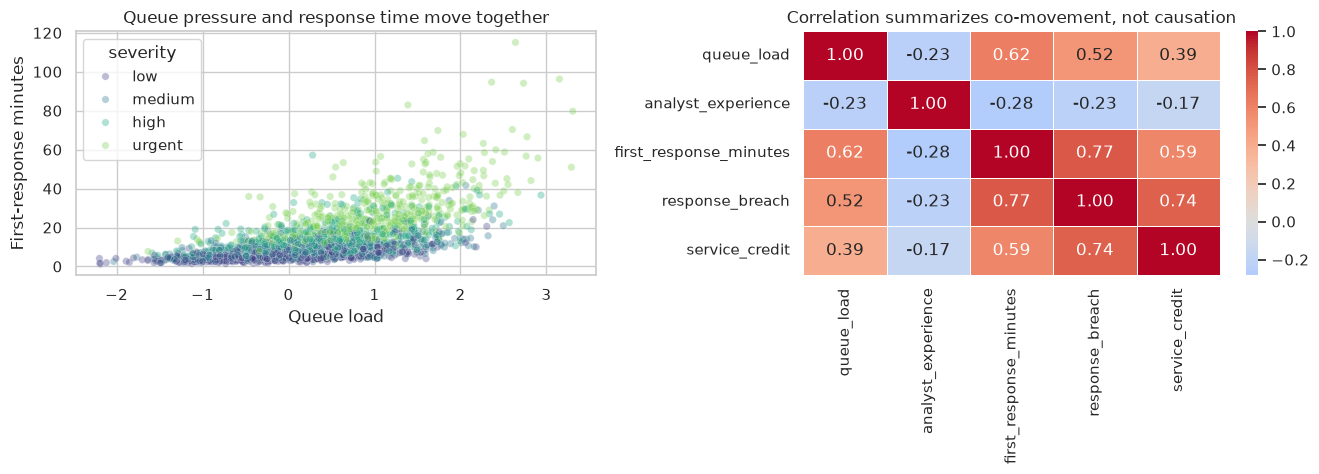

In [11]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
plot_sample = tickets.sample(n=2500, random_state=2077)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.9))

sns.scatterplot(
    data=plot_sample,
    x="queue_load",
    y="first_response_minutes",
    hue="severity",
    alpha=0.35,
    s=28,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Queue pressure and response time move together")
axes[0].set_xlabel("Queue load")
axes[0].set_ylabel("First-response minutes")

corr_table = tickets[["queue_load", "analyst_experience", "first_response_minutes", "response_breach", "service_credit"]].corr()
sns.heatmap(corr_table, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title("Correlation summarizes co-movement, not causation")

plt.tight_layout()
plt.show()


The variance numbers remind us that expectations are not guarantees. Ticket-level service credit is especially spiky because many tickets cost nothing while breached priority tickets trigger a large discrete payment.

The covariance and correlation summaries show systematic co-movement. Queue load tends to rise with response time, while analyst experience tends to move in the opposite direction. Those patterns are operationally meaningful, but we should still speak carefully: co-movement is not yet a causal claim.

That discipline will matter later when the course turns to regression and causal inference. For now, the important point is that probability gives us a way to quantify both average behavior and the instability around it.

## 8. Using Expected Value for a Planning Recommendation

Suppose the operations team is considering a premium support promise for priority-contract sellers. The finance and service teams care about at least four quantities:

- expected response time;
- breach probability;
- expected credit cost per ticket;
- probability of a very expensive operational day.

Probability and expectation now become managerial tools. They guide what kinds of days the business should expect if it makes the promise.


In [12]:
# Build a summary table that supports the interpretation in the surrounding notes.
priority_summary = pd.DataFrame(
    [
        {
            "metric": "Expected response minutes for priority tickets",
            "value": priority_tickets["first_response_minutes"].mean(),
        },
        {
            "metric": "Breach probability for priority tickets",
            "value": priority_tickets["response_breach"].mean(),
        },
        {
            "metric": "Expected credit per priority ticket",
            "value": priority_tickets["service_credit"].mean(),
        },
        {
            "metric": "Expected daily credit at 260 priority tickets/day",
            "value": priority_tickets["service_credit"].mean() * tickets_per_day,
        },
        {
            "metric": "Probability daily credit exceeds 9,000",
            "value": (daily_metrics["total_service_credit"] > 9000).mean(),
        },
        {
            "metric": "90th percentile of daily credit",
            "value": daily_metrics["total_service_credit"].quantile(0.90),
        },
    ]
)

smart_display(priority_summary)


,metric,value
0,Expected response minutes for priority tickets,15.055
1,Breach probability for priority tickets,0.361
2,Expected credit per priority ticket,32.482
3,Expected daily credit at 260 priority tickets/day,8445.365
4,"Probability daily credit exceeds 9,000",0.175
5,90th percentile of daily credit,9360.000


The priority-ticket summary turns probability into a planning recommendation. The breach probability is large enough to create a material expected service credit, and the simulated daily-cost distribution shows that expensive days occur with meaningful frequency.

That is the main implication for the premium support promise. The average response time alone is not enough. Leadership also needs the breach probability, expected credit exposure, and upper-tail daily cost before deciding whether the promise is operationally supportable.


In [13]:
# Simulate data or resample observations to study variability and uncertainty.
expected_credit = priority_tickets["service_credit"].mean()
breach_prob = priority_tickets["response_breach"].mean()
prob_expensive_day = (daily_metrics["total_service_credit"] > 9000).mean()

recommendation = (
    "The premium promise is not yet operationally comfortable. Expected credit cost and the chance of expensive days remain high enough that leadership should improve queue pressure or staffing before broad rollout."
    if (expected_credit > 18) or (breach_prob > 0.18) or (prob_expensive_day > 0.15)
    else "The premium promise looks operationally supportable under the current simulated workflow, though ongoing monitoring would still be required."
)

smart_display(recommendation)


'The premium promise is not yet operationally comfortable. Expected credit cost and the chance of expensive days remain high enough that leadership should improve queue pressure or staffing before broad rollout.'

This section shows what probability looks like when it reaches the decision table. The expected credit per ticket is a budget number. The breach probability is a service-reliability number. The probability of an expensive day is a risk-management number. None of them alone is enough, but together they describe the operational consequences of the promise.

Notice also what expectation does and does not do. It summarizes the center of the financial exposure, but it does not erase variability. A promise can have an acceptable average cost and still generate unpleasant tail days. This is why expected value is central, but not sufficient.

## Wrap-Up

We built the first real probability layer for the course:

1. Operational uncertainty can be structured and still genuinely random.
2. Events let us talk about uncertain conditions such as urgency, channel, and breach status.
3. Random variables convert uncertain outcomes into analyzable numerical quantities.
4. Expectation is both a long-run average and a practical planning statistic.
5. The law of total expectation explains how overall means are assembled from regime-specific behavior.
6. Variance and covariance quantify instability and co-movement without yet making causal claims.
7. Probability becomes most valuable when it informs real decisions about cost, service quality, and risk.

The next notebooks will build on this foundation by developing distributions, tail behavior, sampling, and inferential uncertainty in more detail.


## References

- Gigerenzer, G., & Hoffrage, U. (1995). *How to improve Bayesian reasoning without instruction: Frequency formats*. *Psychological Review*, 102(4), 684-704. [https://doi.org/10.1037/0033-295X.102.4.684](https://doi.org/10.1037/0033-295X.102.4.684)
- Peterson, C. R., & Beach, L. R. (1967). *Man as an intuitive statistician*. *Psychological Bulletin*, 68(1), 29-46. [https://doi.org/10.1037/h0024722](https://doi.org/10.1037/h0024722)
- Spiegelhalter, D., Pearson, M., & Short, I. (2011). *Visualizing uncertainty about the future*. *Science*, 333(6048), 1393-1400. [https://doi.org/10.1126/science.1191181](https://doi.org/10.1126/science.1191181)
- Tukey, J. W. (1962). *The future of data analysis*. *The Annals of Mathematical Statistics*, 33(1), 1-67. [https://doi.org/10.1214/aoms/1177704711](https://doi.org/10.1214/aoms/1177704711)
- Tversky, A., & Kahneman, D. (1971). *Belief in the law of small numbers*. *Psychological Bulletin*, 76(2), 105-110. [https://doi.org/10.1037/h0031322](https://doi.org/10.1037/h0031322)
